In [6]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import ticker
from numerize.numerize import numerize
import os

In [9]:
con=sqlite3.connect('../data/zephyr.sqlite')

In [10]:
cursor = con.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

print(cursor.fetchall())

[('metadata',), ('t',)]


In [11]:
cursor.execute("SELECT * FROM metadata;")
names = list(map(lambda x: x[0], cursor.description))
names

['timestamp', 'Project', 'elapsed_s']

In [12]:
df = pd.read_sql_query("SELECT * FROM t ;",con)

df_src=df.loc[(df['Language']=='C/C++ Header') |
       (df['Language']=='C') |
       (df['Language']=='C++') |
       (df['Language']=='Assembly') 
      ].copy()

df_src['base_dir']=df_src['File_dirname'].apply( lambda x: (x.split("/")[0]))

df_counts=df_src.groupby(['Project','base_dir']).sum(numeric_only=True).copy()

In [13]:
df_counts

nBlank  nComment   nCode    nScaled
Project base_dir                                     
v1.0.0  arch        2741      8593    6680    4940.52
        boards       340       972    1509    1168.60
        doc          104       256     307     262.61
        drivers     4779      7315   16095   13014.53
        include     2964     10400    9105    9105.00
...                  ...       ...     ...        ...
v3.7.0  samples    22659     12214  105147   86124.47
        scripts      775      1708    2730    2220.32
        soc        11534     20254   47989   42617.43
        subsys    113243     66026  472829  375287.43
        tests      98358     69977  367668  286860.20

[606 rows x 4 columns]

In [14]:
df_counts.drop(['nBlank','nComment','nScaled'],axis=1, inplace=True)

In [15]:
df_counts_pivot=df_counts.pivot_table(index="Project",columns="base_dir", fill_value=0 )
df_counts_pivot

nCode                                                     \
base_dir     arch   boards    doc   drivers    dts        ext     fs   
Project                                                                
v1.0.0     6680.0   1509.0  307.0   16095.0    0.0        0.0    0.0   
v1.1.0     6829.0   1359.0  321.0   16822.0    0.0        0.0    0.0   
v1.10.0   18908.0   3362.0  179.0   63618.0  164.0  2405624.0    0.0   
v1.11.0   22203.0   5005.0  179.0   70315.0  175.0  2504393.0    0.0   
v1.12.0   22606.0   5309.0  179.0   80865.0  233.0  2709786.0    0.0   
v1.13.0   24000.0   6411.0  179.0   91706.0  257.0  2924678.0    0.0   
v1.14.0   16116.0   8409.0   29.0  112526.0   21.0  3465318.0    0.0   
v1.14.1   16103.0   8413.0   29.0  112675.0   21.0  3465318.0    0.0   
v1.14.2   16134.0   8413.0   29.0  112784.0   21.0  3465318.0    0.0   
v1.14.3   16197.0   8413.0   29.0  112925.0   21.0  3465335.0    0.0   
v1.2.0     7448.0     87.0  321.0   27198.0    0.0        0.0    0.0   
v1.3.0     7680.0    136.0  321.0   35077.0    0.0        0.0    0.0   
v1.4.0     8541.0   1065.0  321.0   34376.0    0.0    66882.0    0.0   
v1.5.0     8993.0   1063.0    0.0   38009.0    0.0   155305.0  395.0   
v1.6.0     9585.0   1098.0   29.0   41046.0    0.0  1077616.0    0.0   
v1.6.1     9593.0   1098.0   29.0   41046.0    0.0  1078904.0    0.0   
v1.7.0    14953.0   1733.0  179.0   50479.0    0.0  1427956.0    0.0   
v1.7.1    14953.0   1733.0  179.0   50479.0    0.0  1428026.0    0.0   
v1.8.0    15895.0   2067.0  275.0   60287.0  133.0  1736227.0    0.0   
v1.9.0    17256.0   2329.0  275.0   59199.0  157.0  1732725.0    0.0   
v1.9.1    17256.0   2329.0  275.0   59199.0  157.0  1732725.0    0.0   
v1.9.2    17256.0   2329.0  275.0   59199.0  157.0  1732725.0    0.0   
v2.0.0    16863.0   8775.0   29.0  135544.0   21.0    30369.0    0.0   
v2.1.0    14527.0  10081.0   29.0  142637.0   21.0    32577.0    0.0   
v2.2.0    16227.0  11875.0   29.0  154434.0  266.0    32577.0    0.0   
v2.2.1    16227.0  11875.0   29.0  154434.0  266.0    32577.0    0.0   
v2.3.0    16868.0  12263.0   29.0  172113.0  381.0        0.0    0.0   
v2.4.0    17441.0  13408.0   29.0  192123.0  386.0        0.0    0.0   
v2.5.0    20893.0  10205.0   29.0  219911.0  386.0        0.0    0.0   
v2.6.0    22572.0  10459.0   29.0  240913.0  436.0        0.0    0.0   
v2.7.0    23212.0  11430.0   29.0  259890.0  456.0        0.0    0.0   
v2.7.1    23212.0  11430.0   29.0  259940.0  456.0        0.0    0.0   
v2.7.2    23262.0  11430.0   29.0  260234.0  456.0        0.0    0.0   
v2.7.3    23262.0  11430.0   29.0  260252.0  456.0        0.0    0.0   
v2.7.4    23262.0  11430.0   29.0  260252.0  456.0        0.0    0.0   
v2.7.5    23262.0  11430.0   29.0  260254.0  456.0        0.0    0.0   
v2.7.6    23262.0  11430.0   29.0  260290.0  456.0        0.0    0.0   
v3.0.0    26299.0  12327.0   29.0  285281.0  456.0        0.0    0.0   
v3.1.0    26967.0   6137.0   29.0  300523.0  417.0        0.0    0.0   
v3.2.0    27468.0   5356.0   29.0  324437.0  417.0        0.0    0.0   
v3.3.0    28336.0   5742.0   29.0  357997.0  417.0        0.0    0.0   
v3.4.0    29236.0   5950.0   29.0  410025.0  417.0        0.0    0.0   
v3.5.0    30673.0   6302.0   29.0  456671.0  417.0        0.0    0.0   
v3.6.0    31954.0   6604.0   29.0  513628.0  417.0        0.0    0.0   
v3.7.0    33654.0   6874.0  220.0  578924.0  419.0        0.0    0.0   

                                                                          \
base_dir   include   kernel      lib    misc  modules      net   samples   
Project                                                                    
v1.0.0      9105.0   6988.0   3374.0   377.0      0.0  47409.0   25483.0   
v1.1.0      9389.0   6992.0   3401.0   377.0      0.0  47628.0    7005.0   
v1.10.0    22076.0   5542.0   2303.0   421.0      0.0      0.0   26353.0   
v1.11.0    23088.0   6650.0   2431.0   504.0      0.0      0.0   28147.0   
v1.12.0    24984.0   61

In [16]:
df_plot=df_counts_pivot.filter(regex="\.0$", axis=0).copy()

In [17]:
df_plot.rename(index={'v1.0.0':'v1.00.0',
                      'v1.1.0':'v1.01.0',
                      'v1.2.0':'v1.02.0',
                      'v1.3.0':'v1.03.0',
                      'v1.4.0':'v1.04.0',
                      'v1.5.0':'v1.05.0',
                      'v1.6.0':'v1.06.0',
                      'v1.7.0':'v1.07.0',
                      'v1.8.0':'v1.08.0',
                      'v1.9.0':'v1.09.0',
                     
                     }, inplace=True)

In [18]:
df_plot.sort_index(inplace=True)
df_plot

nCode                                                     \
base_dir     arch   boards    doc   drivers    dts        ext     fs   
Project                                                                
v1.00.0    6680.0   1509.0  307.0   16095.0    0.0        0.0    0.0   
v1.01.0    6829.0   1359.0  321.0   16822.0    0.0        0.0    0.0   
v1.02.0    7448.0     87.0  321.0   27198.0    0.0        0.0    0.0   
v1.03.0    7680.0    136.0  321.0   35077.0    0.0        0.0    0.0   
v1.04.0    8541.0   1065.0  321.0   34376.0    0.0    66882.0    0.0   
v1.05.0    8993.0   1063.0    0.0   38009.0    0.0   155305.0  395.0   
v1.06.0    9585.0   1098.0   29.0   41046.0    0.0  1077616.0    0.0   
v1.07.0   14953.0   1733.0  179.0   50479.0    0.0  1427956.0    0.0   
v1.08.0   15895.0   2067.0  275.0   60287.0  133.0  1736227.0    0.0   
v1.09.0   17256.0   2329.0  275.0   59199.0  157.0  1732725.0    0.0   
v1.10.0   18908.0   3362.0  179.0   63618.0  164.0  2405624.0    0.0   
v1.11.0   22203.0   5005.0  179.0   70315.0  175.0  2504393.0    0.0   
v1.12.0   22606.0   5309.0  179.0   80865.0  233.0  2709786.0    0.0   
v1.13.0   24000.0   6411.0  179.0   91706.0  257.0  2924678.0    0.0   
v1.14.0   16116.0   8409.0   29.0  112526.0   21.0  3465318.0    0.0   
v2.0.0    16863.0   8775.0   29.0  135544.0   21.0    30369.0    0.0   
v2.1.0    14527.0  10081.0   29.0  142637.0   21.0    32577.0    0.0   
v2.2.0    16227.0  11875.0   29.0  154434.0  266.0    32577.0    0.0   
v2.3.0    16868.0  12263.0   29.0  172113.0  381.0        0.0    0.0   
v2.4.0    17441.0  13408.0   29.0  192123.0  386.0        0.0    0.0   
v2.5.0    20893.0  10205.0   29.0  219911.0  386.0        0.0    0.0   
v2.6.0    22572.0  10459.0   29.0  240913.0  436.0        0.0    0.0   
v2.7.0    23212.0  11430.0   29.0  259890.0  456.0        0.0    0.0   
v3.0.0    26299.0  12327.0   29.0  285281.0  456.0        0.0    0.0   
v3.1.0    26967.0   6137.0   29.0  300523.0  417.0        0.0    0.0   
v3.2.0    27468.0   5356.0   29.0  324437.0  417.0        0.0    0.0   
v3.3.0    28336.0   5742.0   29.0  357997.0  417.0        0.0    0.0   
v3.4.0    29236.0   5950.0   29.0  410025.0  417.0        0.0    0.0   
v3.5.0    30673.0   6302.0   29.0  456671.0  417.0        0.0    0.0   
v3.6.0    31954.0   6604.0   29.0  513628.0  417.0        0.0    0.0   
v3.7.0    33654.0   6874.0  220.0  578924.0  419.0        0.0    0.0   

                                                                          \
base_dir   include   kernel      lib    misc  modules      net   samples   
Project                                                                    
v1.00.0     9105.0   6988.0   3374.0   377.0      0.0  47409.0   25483.0   
v1.01.0     9389.0   6992.0   3401.0   377.0      0.0  47628.0    7005.0   
v1.02.0    10280.0   7153.0   3417.0   377.0      0.0  48490.0    7632.0   
v1.03.0    10665.0   7333.0   3429.0  1784.0      0.0  50006.0    9121.0   
v1.04.0    11208.0   7686.0   1644.0  1784.0      0.0  51482.0   11327.0   
v1.05.0    12379.0   7711.0   1692.0  1785.0      0.0  52728.0   16084.0   
v1.06.0    14147.0   4350.0   2707.0  1860.0      0.0  39909.0   17357.0   
v1.07.0    17160.0   4654.0   2038.0   345.0      0.0      0.0   23081.0   
v1.08.0    17832.0   4348.0   2416.0   403.0      0.0      0.0   22056.0   
v1.09.0    19612.0   4504.0   2466.0   356.0      0.0      0.0   24642.0   
v1.10.0    22076.0   5542.0   2303.0   421.0      0.0      0.0   26353.0   
v1.11.0    23088.0   6650.0   2431.0   504.0      0.0      0.0   28147.0   
v1.12.0    24984.0   6172.0   4662.0   504.0      0.0      0.0   32041.0   
v1.13.0    27711.0   6418.0   5650.0   509.0      0.0      0.0   33585.0   
v1.14.0    30154.0   6557.0   8909.0     0.0      0.0      0.0   34180.0   
v2.0.0     33279.0   6657.0  10720.0     0.0      0.0      0.0   36129.0   
v2.1.0     34825.0   6710.0  10845.0     0.0      0.0      0.0   38933.0   
v2.2.0     36438.0   6895.0  11452.0     0.

In [19]:
df_plot.columns=[c[1] for c in df_plot.columns.values]

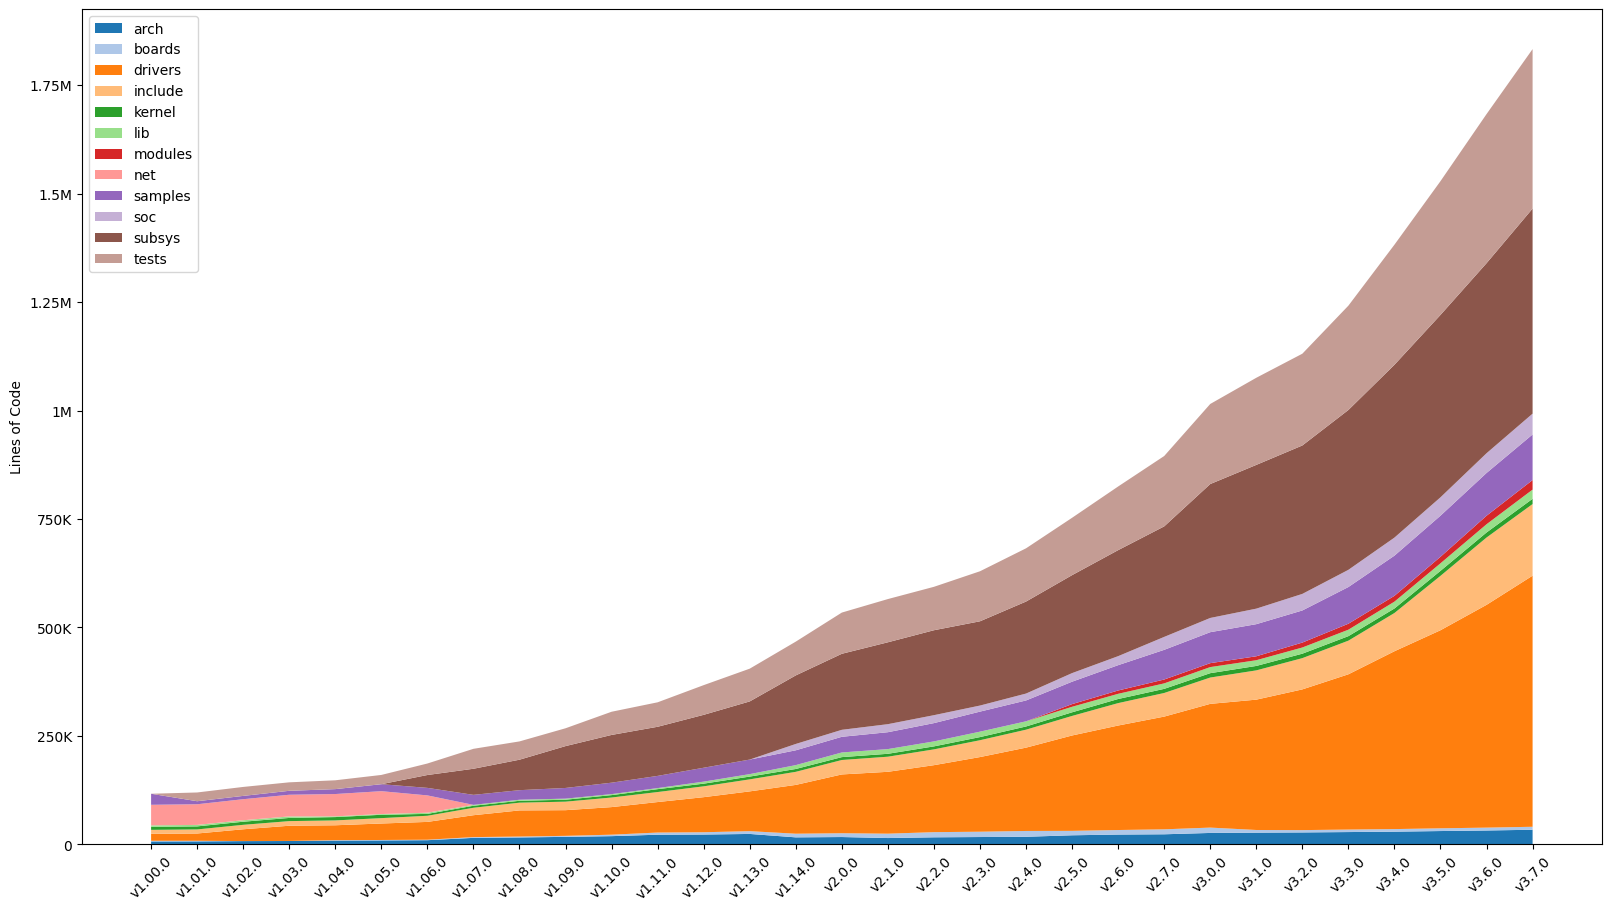

In [31]:
# Choose some nice levels
plt.rcParams["figure.figsize"] = [16, 9]
plt.rcParams["figure.autolayout"] = True

legend=['arch','boards','kernel','soc','modules','lib','include','subsys','drivers', 'samples', 'tests', 'net' ]
#legend=['samples' ]
legend=sorted(legend)
fig, ax = plt.subplots(figsize=(16,9), constrained_layout=True)
ax.stackplot(df_plot.index, [df_plot[name] for name in legend],
             labels=legend, colors=mpl.colormaps["tab20"](np.arange(len(legend)))
            )
ax.set_ylabel("Lines of Code")             
ax.yaxis.set_major_formatter(lambda x,pos: f"{numerize(x)}")
ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(),rotation=45)
ax.legend(loc='upper left')
             
fig.savefig('../figures/zephyr-growth.svg', format='svg')     